# 02 — Feature Engineering
## Derived Features for Battery Lifecycle Prediction

**Objective:** Compute and validate all derived features for downstream ML models:
1. **SOC** (State of Charge) via Coulomb counting per cycle
2. **SOH** (State of Health) as % of nominal capacity
3. **RUL** (Remaining Useful Life) in cycles until EOL
4. **12 per-cycle scalar features** for classical ML
5. **Fixed-length sequence dataset** for deep learning (LSTM, Transformer)

Outputs saved to `artifacts/`:
- `battery_features.csv` — per-cycle scalar feature matrix
- `battery_sequences.npz` — windowed sequences for sequential models

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data.loader import (
    load_metadata, load_discharge_capacities, load_cycle_csv,
    get_eol_threshold, get_battery_ids, NOMINAL_CAPACITY_AH,
)
from src.data.features import (
    compute_soc, compute_soh, compute_rul_series,
    classify_degradation_state, DEGRADATION_LABELS,
    extract_cycle_features, build_battery_feature_dataset,
)
from src.data.preprocessing import (
    make_sliding_windows, downsample_to_bins, group_battery_split,
    fit_and_save_scaler, FEATURE_COLS_SCALAR, SEQUENCE_FEATURE_COLS,
)
from src.utils.plotting import save_fig
from src.utils.config import ARTIFACTS_DIR, FIGURES_DIR, WINDOW_SIZE, N_BINS

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.3)
print("Setup complete.")

Setup complete.


## 1. SOC Computation via Coulomb Counting

For each discharge cycle, compute State of Charge:
$$\Delta Q_i = |I_i| \cdot \Delta t_i / 3600 \quad \text{(Ah)}$$
$$\text{SOC}_i = 100 \times \left(1 - \frac{\sum_{j=0}^{i} \Delta Q_j}{Q_{\text{nom}}}\right)$$

We demonstrate on several discharge cycles from battery B0005 — early vs. late cycles.

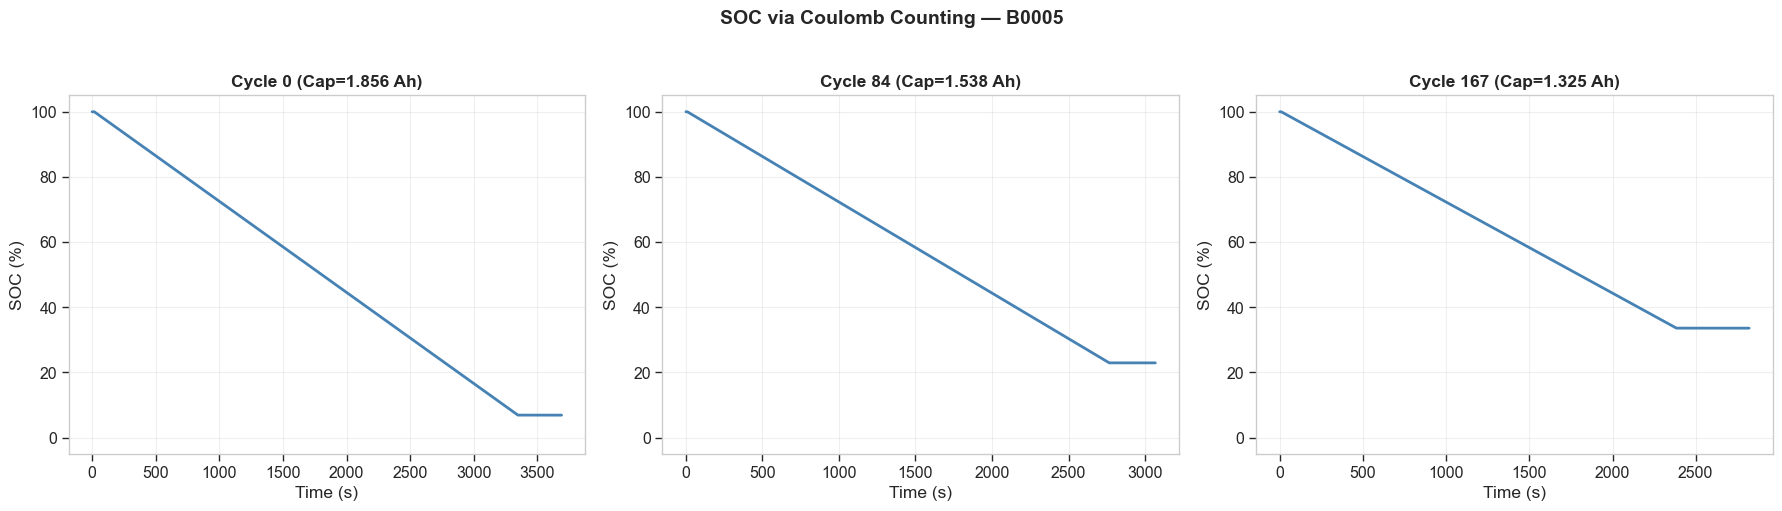

In [2]:
meta = load_metadata(exclude_corrupt=True, parse_dates=False)
bid = "B0005"
dis_meta = meta[(meta["battery_id"] == bid) & (meta["type"] == "discharge")].copy()
dis_meta = dis_meta.sort_values("test_id").reset_index(drop=True)
dis_meta["cycle_number"] = range(len(dis_meta))

# Pick early (cycle 1), middle, and late cycles
cycle_indices = [0, len(dis_meta) // 2, len(dis_meta) - 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ci in zip(axes, cycle_indices):
    row = dis_meta.iloc[ci]
    cdf = load_cycle_csv(row["uid"])
    soc = compute_soc(cdf)
    ax.plot(cdf["Time"], soc, linewidth=2, color="steelblue")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("SOC (%)")
    ax.set_title(f"Cycle {ci} (Cap={row['Capacity']:.3f} Ah)", fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 105)

fig.suptitle(f"SOC via Coulomb Counting — {bid}", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "soc_coulomb_counting_demo")
plt.show()

## 2. SOH Degradation with Trend Lines

Fit both linear and exponential degradation models to the SOH curve for each battery.

$$\text{SOH}_{\text{linear}} = a \cdot n + b$$
$$\text{SOH}_{\text{exp}} = A \cdot e^{\lambda n}$$

The exponential model better captures the accelerating degradation in later cycles (knee-point behavior).

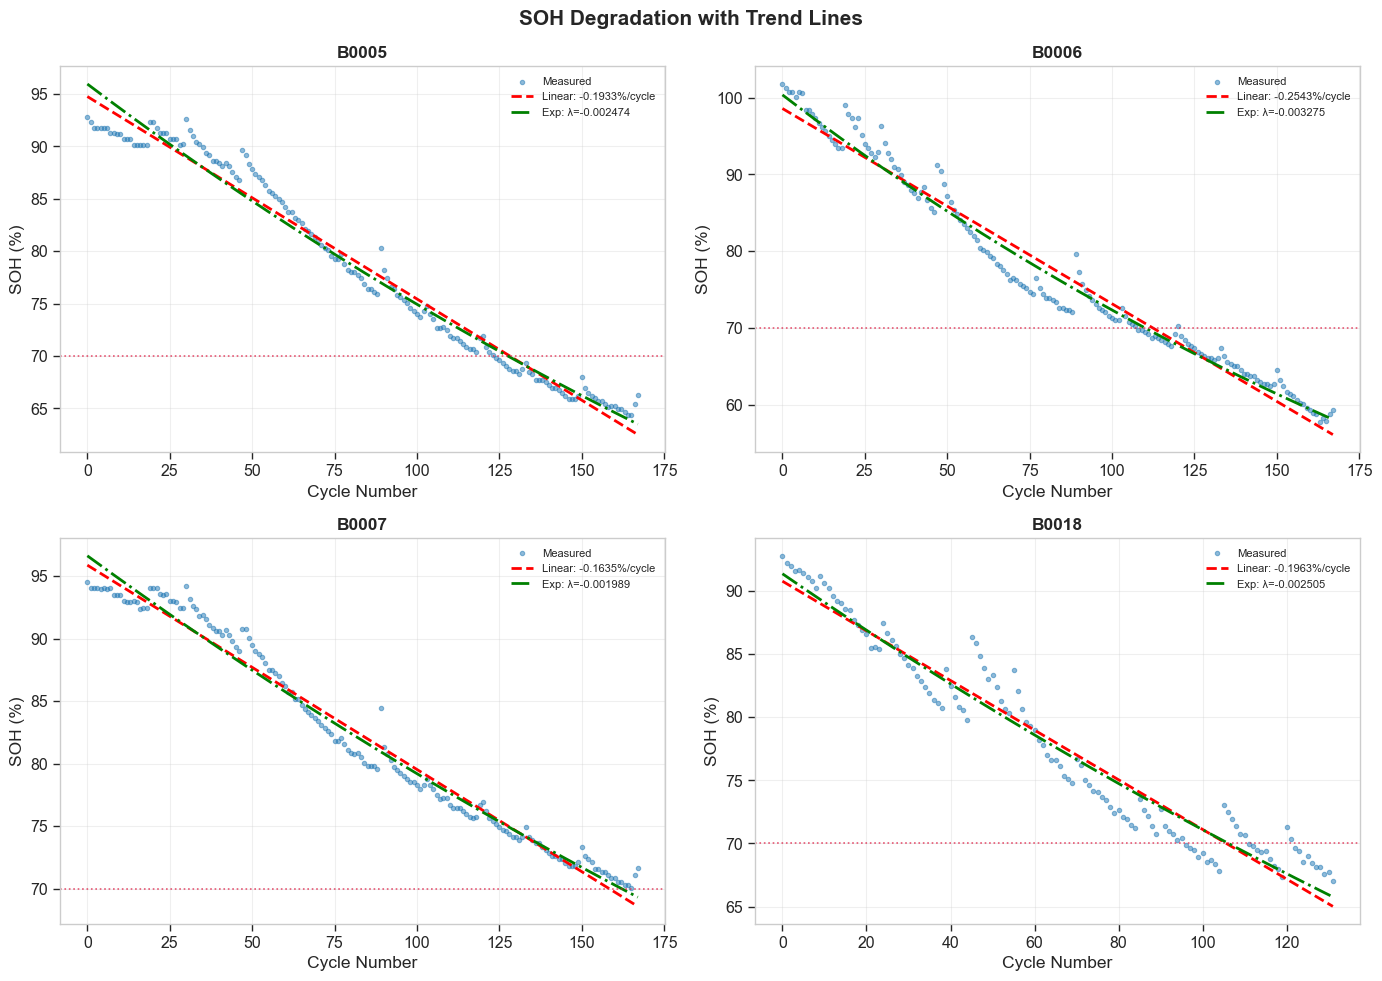

In [3]:
cap_df = load_discharge_capacities(exclude_corrupt=True, drop_zero=True)
cap_df["SoH"] = compute_soh(cap_df["Capacity"])

# Plot for 4 representative batteries
rep_bats = ["B0005", "B0006", "B0007", "B0018"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, bid in zip(axes.flat, rep_bats):
    sub = cap_df[cap_df["battery_id"] == bid]
    x = sub["cycle_number"].values.astype(float)
    y = sub["SoH"].values
    
    ax.scatter(x, y, s=10, alpha=0.5, label="Measured")
    
    # Linear fit
    coeffs = np.polyfit(x, y, 1)
    ax.plot(x, np.polyval(coeffs, x), "r--", linewidth=2,
            label=f"Linear: {coeffs[0]:.4f}%/cycle")
    
    # Exponential fit
    try:
        valid = y > 0
        exp_coeffs = np.polyfit(x[valid], np.log(y[valid]), 1)
        y_exp = np.exp(exp_coeffs[1]) * np.exp(exp_coeffs[0] * x)
        ax.plot(x, y_exp, "g-.", linewidth=2,
                label=f"Exp: \u03bb={exp_coeffs[0]:.6f}")
    except:
        pass
    
    eol = get_eol_threshold(bid)
    ax.axhline(y=eol / NOMINAL_CAPACITY_AH * 100, color="crimson", linestyle=":", alpha=0.7)
    ax.set_title(f"{bid}", fontweight="bold")
    ax.set_xlabel("Cycle Number")
    ax.set_ylabel("SOH (%)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("SOH Degradation with Trend Lines", fontsize=15, fontweight="bold")
plt.tight_layout()
save_fig(fig, "soh_degradation_trends")
plt.show()

## 3. RUL Computation

Remaining Useful Life (cycles):
$$\text{RUL}_i = n_{\text{EOL}} - i$$

where $n_{\text{EOL}}$ is the first cycle where capacity drops below the EOL threshold.

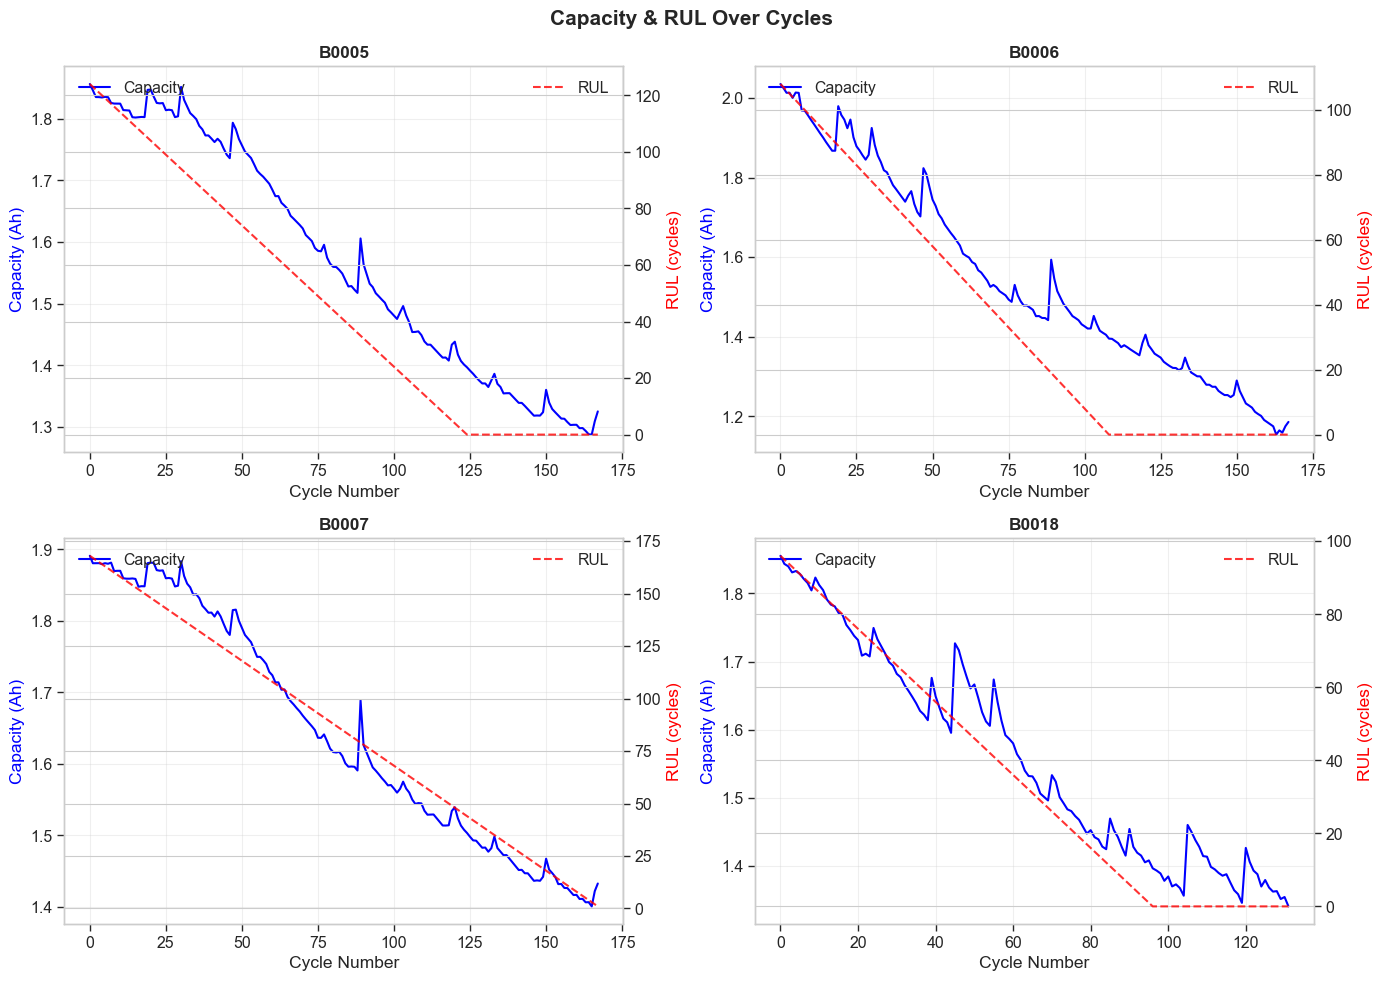

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, bid in zip(axes.flat, rep_bats):
    sub = cap_df[cap_df["battery_id"] == bid].copy()
    eol = get_eol_threshold(bid)
    rul = compute_rul_series(sub["Capacity"], eol)
    
    ax2 = ax.twinx()
    ax.plot(sub["cycle_number"], sub["Capacity"], "b-", linewidth=1.5, label="Capacity")
    ax2.plot(sub["cycle_number"], rul, "r--", linewidth=1.5, label="RUL", alpha=0.8)
    
    ax.set_xlabel("Cycle Number")
    ax.set_ylabel("Capacity (Ah)", color="blue")
    ax2.set_ylabel("RUL (cycles)", color="red")
    ax.set_title(f"{bid}", fontweight="bold")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

fig.suptitle("Capacity & RUL Over Cycles", fontsize=15, fontweight="bold")
plt.tight_layout()
save_fig(fig, "capacity_and_rul")
plt.show()

## 4. Build Per-Cycle Scalar Feature Dataset

Extract 12 per-cycle features from each discharge cycle:

| Feature | Description |
|---|---|
| `cycle_number` | Sequential discharge cycle index |
| `ambient_temperature` | Operating temperature (°C) |
| `peak_voltage` | Maximum voltage in cycle |
| `min_voltage` | Minimum voltage (cutoff) |
| `voltage_range` | peak - min voltage |
| `avg_current` | Mean |current| during discharge |
| `avg_temp` | Mean cell temperature |
| `temp_rise` | max_temp - min_temp |
| `cycle_duration` | Total cycle time (s) |
| `Re` | Nearest impedance: electrolyte resistance |
| `Rct` | Nearest impedance: charge-transfer resistance |
| `delta_capacity` | Capacity change from previous cycle |

**Targets:** SOH (%), RUL (cycles), degradation_state (0–3)

In [5]:
print("Building per-cycle feature dataset...")
print("This will read all discharge CSVs — may take a few minutes.\n")

features_df = build_battery_feature_dataset(exclude_corrupt=True, verbose=True)
print(f"\nDataset shape: {features_df.shape}")
print(f"Columns: {list(features_df.columns)}")
display(features_df.head(10))

# Save
features_path = ARTIFACTS_DIR / "battery_features.csv"
features_df.to_csv(features_path, index=False)
print(f"\nSaved to: {features_path}")

Building per-cycle feature dataset...
This will read all discharge CSVs — may take a few minutes.



Extracting features:   0%|                            | 0/2678 [00:00<?, ?it/s]

Extracting features:   2%|▍                 | 61/2678 [00:00<00:04, 602.56it/s]

Extracting features:   5%|▊                | 122/2678 [00:00<00:04, 540.81it/s]

Extracting features:   7%|█▏               | 180/2678 [00:00<00:04, 554.46it/s]

...

Extracting features:  98%|███████████████▋| 2633/2678 [00:05<00:00, 515.11it/s]

Extracting features: 100%|████████████████| 2678/2678 [00:05<00:00, 482.16it/s]


Dataset shape: (2678, 19)
Columns: ['battery_id', 'cycle_number', 'Capacity', 'ambient_temperature', 'datetime', 'SoH', 'RUL', 'degradation_state', 'Re', 'Rct', 'peak_voltage', 'min_voltage', 'voltage_range', 'avg_current', 'avg_temp', 'temp_rise', 'cycle_duration', 'delta_capacity', 'coulombic_efficiency']


,battery_id,cycle_number,Capacity,ambient_temperature,datetime,SoH,RUL,degradation_state,Re,Rct,peak_voltage,min_voltage,voltage_range,avg_current,avg_temp,temp_rise,cycle_duration,delta_capacity,coulombic_efficiency
0,B0005,0,1.856487,24,2008-04-02 15:25:41,92.824371,124,0,0.044669,0.069456,4.191492,2.612467,1.579024,1.818712,32.572328,14.656188,3690.234,0.000000,NaN
1,B0005,1,1.846327,24,2008-04-02 19:43:48,92.316362,123,0,0.046687,0.076275,4.189773,2.587209,1.602564,1.817644,32.725235,14.347450,3672.344,-0.010160,NaN
2,B0005,2,1.835349,24,2008-04-03 00:01:06,91.767460,122,0,0.044843,0.067972,4.188187,2.651917,1.536270,1.816542,32.642862,14.084531,3651.641,-0.010978,NaN
3,B0005,3,1.835263,24,2008-04-03 04:16:37,91.763126,121,0,0.046195,0.074534,4.188461,2.592948,1.595513,1.825618,32.514876,14.110061,3631.563,-0.000087,NaN
4,B0005,4,1.834646,24,2008-04-03 08:33:25,91.732275,120,0,0.045101,0.068528,4.188299,2.547420,1.640879,1.826148,32.382349,14.146692,3629.172,-0.000617,NaN
5,B0005,5,1.835662,24,2008-04-03 12:55:10,91.783083,119,0,0.045991,0.073427,4.188816,2.520948,1.667868,1.816900,32.434182,14.237268,3652.281,0.001016,NaN
6,B0005,6,1.835146,24,2008-04-03 17:17:16,91.757307,118,0,0.044172,0.068044,4.188392,2.487927,1.700464,1.816838,32.480416,14.245120,3650.828,-0.000516,NaN
7,B0005,7,1.825757,24,2008-04-03 21:28:14,91.287840,117,0,0.045217,0.074648,4.188928,2.665205,1.523723,1.844408,32.410462,13.805806,3572.453,-0.009389,NaN
8,B0005,8,1.824774,24,2008-04-04 01:38:15,91.238693,116,0,0.043787,0.068450,4.189029,2.603858,1.585171,1.854064,32.346141,13.897781,3550.594,-0.000983,NaN
9,B0005,9,1.824613,24,2008-04-04 05:48:08,91.230663,115,0,0.044910,0.073957,4.189223,2.552854,1.636369,1.853659,32.276798,13.965421,3551.250,-0.000161,NaN



Saved to: E:\VIT\aiBatteryLifecycle\artifacts\battery_features.csv


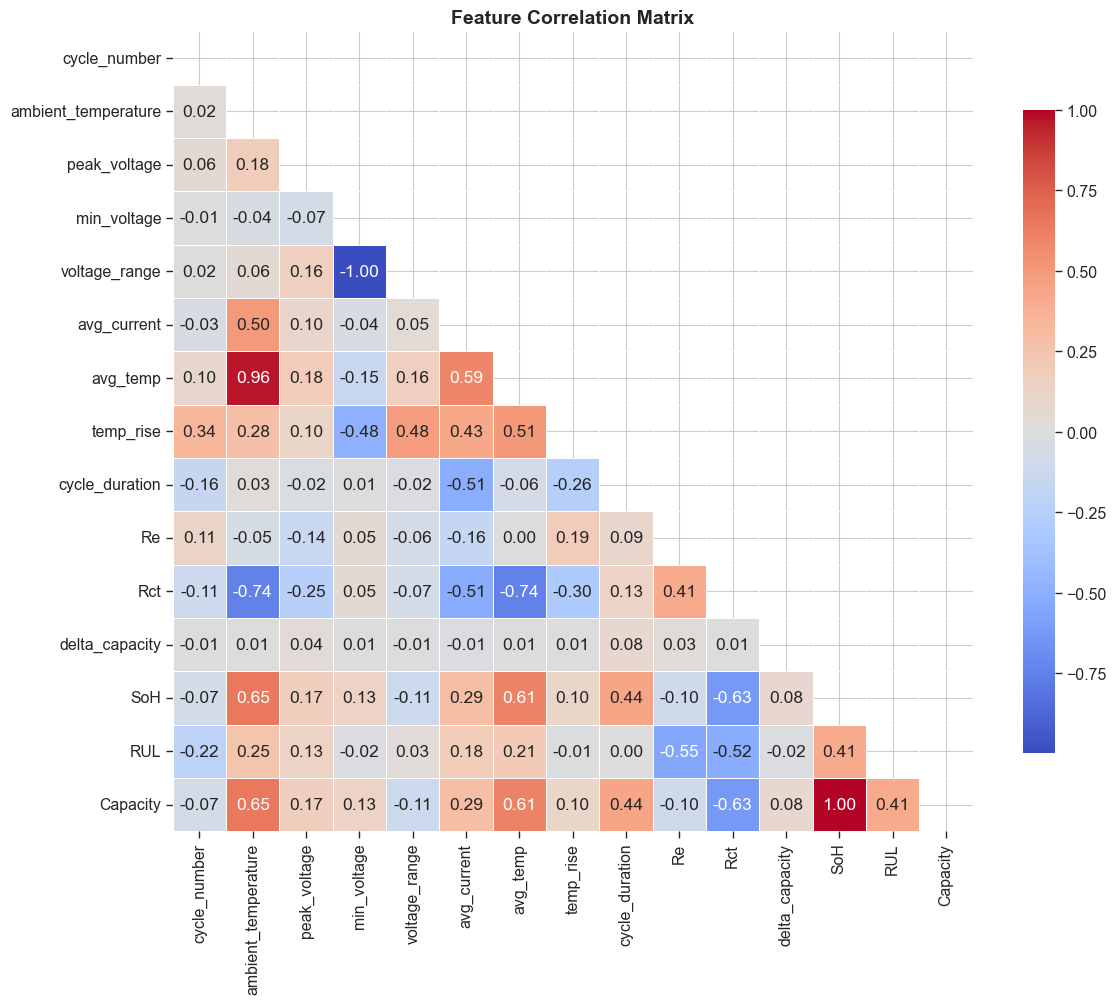

In [6]:
# Feature correlation heatmap
numeric_cols = [c for c in FEATURE_COLS_SCALAR + ["SoH", "RUL", "Capacity"] if c in features_df.columns]
corr = features_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
save_fig(fig, "feature_correlation_heatmap")
plt.show()

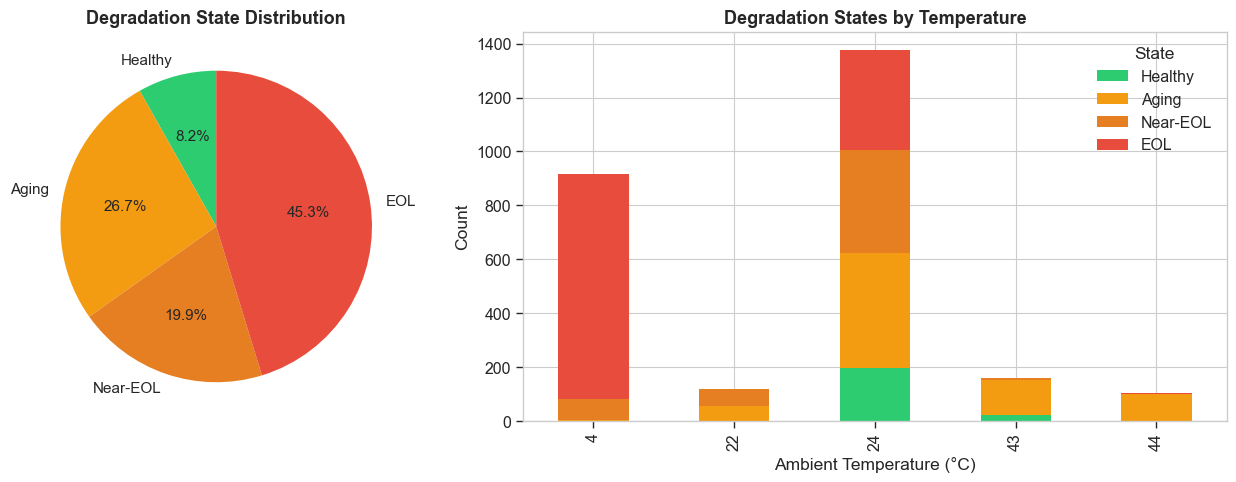

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
state_counts = features_df["degradation_state"].value_counts().sort_index()
labels = [DEGRADATION_LABELS[i] for i in state_counts.index]
colors = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]
axes[0].pie(state_counts, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 11})
axes[0].set_title("Degradation State Distribution", fontsize=13, fontweight="bold")

# Bar chart by temperature
ct = pd.crosstab(features_df["ambient_temperature"], features_df["degradation_state"])
ct.columns = [DEGRADATION_LABELS[c] for c in ct.columns]
ct.plot(kind="bar", stacked=True, ax=axes[1], color=colors[:len(ct.columns)])
axes[1].set_title("Degradation States by Temperature", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Ambient Temperature (°C)")
axes[1].set_ylabel("Count")
axes[1].legend(title="State")

plt.tight_layout()
save_fig(fig, "degradation_state_distribution")
plt.show()

## 5. Sequence Dataset for Deep Learning

For sequential models (LSTM, Transformer), we create:
1. Per-battery capacity sequences → sliding windows of size 32 → target = next cycle SOH
2. Per-battery multi-feature sequences → same windowing with all scalar features

In [8]:
# Build capacity-only sliding windows per battery
all_windows_X = []
all_windows_y = []
battery_ids_seq = []

for bid in sorted(features_df["battery_id"].unique()):
    sub = features_df[features_df["battery_id"] == bid].sort_values("cycle_number")
    cap_vals = sub["SoH"].values
    if len(cap_vals) <= WINDOW_SIZE + 1:
        continue
    X_w, y_w = make_sliding_windows(cap_vals, window_size=WINDOW_SIZE)
    all_windows_X.append(X_w)
    all_windows_y.append(y_w)
    battery_ids_seq.extend([bid] * len(X_w))

X_soh_seq = np.concatenate(all_windows_X, axis=0)
y_soh_seq = np.concatenate(all_windows_y, axis=0)
battery_ids_seq = np.array(battery_ids_seq)

print(f"SOH sequence windows: X={X_soh_seq.shape}, y={y_soh_seq.shape}")

# Build multi-feature sliding windows
feature_cols_for_seq = [c for c in FEATURE_COLS_SCALAR if c in features_df.columns]
all_mf_X, all_mf_y, mf_bids = [], [], []

for bid in sorted(features_df["battery_id"].unique()):
    sub = features_df[features_df["battery_id"] == bid].sort_values("cycle_number")
    vals = sub[feature_cols_for_seq].fillna(0).values
    soh_vals = sub["SoH"].values
    if len(vals) <= WINDOW_SIZE + 1:
        continue
    T = len(vals)
    for i in range(T - WINDOW_SIZE):
        all_mf_X.append(vals[i:i + WINDOW_SIZE])
        all_mf_y.append(soh_vals[i + WINDOW_SIZE])
        mf_bids.append(bid)

X_multi = np.array(all_mf_X)
y_multi = np.array(all_mf_y)
bids_multi = np.array(mf_bids)

print(f"Multi-feature windows: X={X_multi.shape}, y={y_multi.shape}")

# Save
np.savez_compressed(
    str(ARTIFACTS_DIR / "battery_sequences.npz"),
    X_soh=X_soh_seq, y_soh=y_soh_seq, bids_soh=battery_ids_seq,
    X_multi=X_multi, y_multi=y_multi, bids_multi=bids_multi,
)
print(f"Saved to: {ARTIFACTS_DIR / 'battery_sequences.npz'}")

SOH sequence windows: X=(1734, 32, 1), y=(1734,)
Multi-feature windows: X=(1734, 32, 12), y=(1734,)
Saved to: E:\VIT\aiBatteryLifecycle\artifacts\battery_sequences.npz


## 6. Train/Test Split Verification

Verify battery-grouped split has no data leakage.

In [9]:
train_df, test_df = group_battery_split(features_df, train_ratio=0.8)
print(f"Train: {len(train_df)} samples from {train_df['battery_id'].nunique()} batteries")
print(f"Test:  {len(test_df)} samples from {test_df['battery_id'].nunique()} batteries")
print(f"Train batteries: {sorted(train_df['battery_id'].unique())}")
print(f"Test batteries:  {sorted(test_df['battery_id'].unique())}")
overlap = set(train_df["battery_id"]) & set(test_df["battery_id"])
print(f"Overlap: {overlap if overlap else 'NONE ✓ (no leakage)'}")

Train: 2163 samples from 24 batteries
Test:  515 samples from 6 batteries
Train batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0029', 'B0030', 'B0032', 'B0033', 'B0034', 'B0038', 'B0039', 'B0040', 'B0041', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0053', 'B0054', 'B0055', 'B0056']
Test batteries:  ['B0027', 'B0028', 'B0031', 'B0036', 'B0042', 'B0043']
Overlap: NONE ✓ (no leakage)


In [10]:
# Fit and save scalers on training data
from src.data.preprocessing import fit_and_save_scaler

available_cols = [c for c in FEATURE_COLS_SCALAR if c in train_df.columns]
X_train_vals = train_df[available_cols].fillna(0).values

scaler_std = fit_and_save_scaler(X_train_vals, scaler_type="standard", name="features")
scaler_mm = fit_and_save_scaler(X_train_vals, scaler_type="minmax", name="features")

print(f"StandardScaler fitted and saved (mean range: [{scaler_std.mean_.min():.2f}, {scaler_std.mean_.max():.2f}])")
print(f"MinMaxScaler fitted and saved")
print(f"\nFeature Engineering complete. All artifacts saved to: {ARTIFACTS_DIR}")

StandardScaler fitted and saved (mean range: [-0.00, 3283.00])
MinMaxScaler fitted and saved

Feature Engineering complete. All artifacts saved to: E:\VIT\aiBatteryLifecycle\artifacts
